# Fine-Tuning

# Libraries

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.losses import CoSENTLoss, MatryoshkaLoss
from datasets import Dataset
from peft import LoraConfig, TaskType
import torch
import os


2026-05-04 10:01:44.543020: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 10:01:45.096394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/dkusmenko/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving

In [2]:
import os
# This enables memory fragmentation handling specifically for AMD HIP
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
def print_gpu_utilization():
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return

    # On AMD ROCm, 'cuda' functions query the HIP backend
    reserved = torch.cuda.memory_reserved()
    allocated = torch.cuda.memory_allocated()
    total_memory = torch.cuda.get_device_properties(0).total_memory
    
    print(f"Total GPU Mem: {total_memory / 1024**3:.2f} GB")
    print(f"Reserved (Cached): {reserved / 1024**3:.2f} GB")
    print(f"Allocated (Active): {allocated / 1024**3:.2f} GB")
    print(f"Free (Approx): {(total_memory - reserved) / 1024**3:.2f} GB")
    print("-" * 30)

# Run it
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 0.00 GB
Allocated (Active): 0.00 GB
Free (Approx): 15.82 GB
------------------------------


/home/dkusmenko/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:736: UserWarning: Can't initialize amdsmi - Error code: 34
  warnings.warn(f"Can't initialize amdsmi - Error code: {e.err_code}")


# Data Import, Clean, and Sample

In [5]:
# ==========================================
# DATA LOADING & PREPROCESSING
# ==========================================
print("Loading beMTPL16 dataset...")
# Load the Belgian dataset 
full_df = pd.read_csv('beMTPL16.csv')

# Clean and align column names to the expected logic 
# Using 'number_of_liability_claims' as the target 'ClaimNb'
full_df['ClaimNb'] = pd.to_numeric(full_df['number_of_liability_claims'])
full_df['Exposure'] = pd.to_numeric(full_df['exposure']).clip(upper=1.0)
full_df['Frequency'] = full_df['ClaimNb'] / full_df['Exposure']
full_df['has_claim'] = full_df['ClaimNb'] > 0

finetune_df = full_df



Loading beMTPL16 dataset...


In [6]:
finetune_df


,insurance_contract,policy_year,exposure,insured_birth_year,vehicle_age,policy_holder_age,driver_license_age,vehicle_brand,vehicle_model,mileage,...,number_of_liability_claims,number_of_bodily_injury_liability_claims,claim_time,claim_responsibility_rate,driving_training_label,signal,ClaimNb,Exposure,Frequency,has_claim
0,C1,1,0.386301,1945,10,9,40,MERCEDES,ME-1245,30000,...,0,0,00:00,0,No,0,0,0.386301,0.0,False
1,C2,1,0.493151,1941,4,25,24,VOLKSWAGEN,VO-2461,30000,...,0,0,07:45,0,No,0,0,0.493151,0.0,False
2,C3,1,0.290411,1944,0,2,39,AUDI,AU-967,30000,...,0,0,00:00,0,No,0,0,0.290411,0.0,False
3,C4,1,0.336986,1948,1,14,37,LANCIA,LA-2346,30000,...,0,0,18:50,0,No,0,0,0.336986,0.0,False
4,C5,1,0.219178,1928,3,7,59,CITROEN,CI-1258,30000,...,0,0,00:00,100,No,0,0,0.219178,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70786,C58720,4,0.650273,1946,6,1,40,OPEL,OP-3248,30000,...,0,0,00:00,0,No,0,0,0.650273,0.0,False
70787,C58721,4,0.229508,1945,8,13,43,CITROEN,CI-1263,30000,...,0,0,00:00,0,No,0,0,0.229508,0.0,False
70788,C58722,4,0.767760,1937,12,5,44,RENAULT,RE-2061,30000,...,0,0,00:00,0,No,0,0,0.767760,0.0,False
70789,C52079,4,0.289617,1949,3,9,42,CITROEN,CI-1265,30000,...,0,0,00:00,0,No,0,0,0.289617,0.0,False


# Create Prompts

In [ ]:
# ==========================================
# 3. SERIALIZATION (Tabular -> Text)
# ==========================================
def serialize_row_belgian(row):
    """
    Converts a row of Belgian insurance covariates into a natural language prompt.
    Adapted for beMTPL16 columns: vehicle_brand, vehicle_model, catalog_value, etc.
    """
    brand = str(row['vehicle_brand']).strip()
    model = str(row['vehicle_model']).strip()
    training = str(row['driving_training_label']).strip()
    
    return (
        f"You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. "
        f"A policyholder is {2016-row['insured_birth_year']} years old with {row['driver_license_age']} years of driving experience. "
        f"They drive a {brand} {model} with a vehicle horsepower of {row['vehicle_power']}. "
        f"The vehicle is {row['vehicle_age']} years old with a mileage of {row['mileage']}. "
        f"Driving training label: {training}."
    )

print("Serializing rows to text...")
finetune_df['text_desc'] = finetune_df.apply(serialize_row_belgian, axis=1)

Serializing rows to text...


### Example Prompt

In [8]:
finetune_df['text_desc'][0]

'You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. A policyholder is 71 years old with 40 years of driving experience. They drive a MERCEDES ME-1245 with a vehicle horsepower of 75. The vehicle is 10 years old with a mileage of 30000. Driving training label: No.'

'You are an auto insurance underwriter. Evaluate the risk level of a policyholder based strictly on the following insurance-related information. A policyholder is 71 years old with 40 years of driving experience. They drive a MERCEDES ME-1245 with a vehicle horsepower of 75. The vehicle is 10 years old with a mileage of 30000. Driving training label: No.'

# Pair Generation

In [9]:
# ==========================================
# PAIR GENERATION (Metric Learning)
# ==========================================
def generate_pairs(dataframe, num_pairs=150000):
    df = dataframe.copy()
    # Filter unreliable low exposure rows
    valid_df = df[df['Exposure'] > 0.08]
    
    n_contrastive = num_pairs // 2
    n_random = num_pairs - n_contrastive
    
    zeros = valid_df[valid_df['ClaimNb'] == 0]
    claims = valid_df[valid_df['ClaimNb'] > 0]
    
    # Contrastive Sampling
    zeros_batch = zeros.sample(n=n_contrastive, replace=True)
    claims_batch = claims.sample(n=n_contrastive, replace=True)
    
    # Random Sampling
    rand_a_batch = valid_df.sample(n=n_random, replace=True)
    rand_b_batch = valid_df.sample(n=n_random, replace=True)
    
    list_a = pd.concat([zeros_batch, rand_a_batch], ignore_index=True)
    list_b = pd.concat([claims_batch, rand_b_batch], ignore_index=True)
    
    diffs = np.abs(list_a['Frequency'].to_numpy() - list_b['Frequency'].to_numpy())
    scores = 1.0 / (1.0 + 2.0 * diffs)
    
    return Dataset.from_dict({
        "sentence1": list_a['text_desc'].tolist(),
        "sentence2": list_b['text_desc'].tolist(),
        "score": scores.astype(float)
    })

ft_dataset = generate_pairs(finetune_df, num_pairs=150000)

# ==========================================
# CREATE TRAIN/VALIDATION SPLIT FOR MONITORING
# ==========================================
# Split dataset into 80% training, 20% validation
ft_dataset_split = ft_dataset.train_test_split(test_size=0.2, seed=42)
ft_train = ft_dataset_split['train']
ft_val = ft_dataset_split['test']

print(f"Training samples: {len(ft_train)}")
print(f"Validation samples: {len(ft_val)}")

Training samples: 120000
Validation samples: 30000


# Model Setup

In [10]:
# ==========================================
# MODEL SETUP (Qwen + LoRA)
# ==========================================
# NOTE: Ensure you have access to this model on HF Hub or use local path.
model_id = "Qwen/Qwen3-Embedding-0.6B" 

print(f"Loading base model: {model_id}")
model = SentenceTransformer(model_id, trust_remote_code=True, device="cuda" if torch.cuda.is_available() else "cpu")

# Apply LoRA to make fine-tuning feasible and prevent catastrophic forgetting
peft_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

# Attach adapter
model[0].auto_model.add_adapter(peft_config)
model[0].auto_model.enable_input_require_grads()

Loading base model: Qwen/Qwen3-Embedding-0.6B


/home/dkusmenko/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1329: UserWarning: expandable_segments not supported on this platform (Triggered internally at /pytorch/c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


In [11]:
# Replace line 23 with this block to verify LoRA is working
trainable_params = 0
all_param = 0
for name, param in model[0].auto_model.named_parameters():
    all_param += param.numel()
    if param.requires_grad:
        trainable_params += param.numel()

print(f"trainable params: {trainable_params:,} || all params: {all_param:,} || trainable%: {100 * trainable_params / all_param:.2f}%")

trainable params: 2,523,136 || all params: 598,299,648 || trainable%: 0.42%


# Fine-Tuning CoSENT Loss

In [12]:
import torch

def print_gpu_utilization():
    if not torch.cuda.is_available():
        print("No GPU detected.")
        return

    # On AMD ROCm, 'cuda' functions query the HIP backend
    reserved = torch.cuda.memory_reserved()
    allocated = torch.cuda.memory_allocated()
    total_memory = torch.cuda.get_device_properties(0).total_memory
    
    print(f"Total GPU Mem: {total_memory / 1024**3:.2f} GB")
    print(f"Reserved (Cached): {reserved / 1024**3:.2f} GB")
    print(f"Allocated (Active): {allocated / 1024**3:.2f} GB")
    print(f"Free (Approx): {(total_memory - reserved) / 1024**3:.2f} GB")
    print("-" * 30)

# Run it
print_gpu_utilization()

Total GPU Mem: 15.82 GB
Reserved (Cached): 2.23 GB
Allocated (Active): 2.23 GB
Free (Approx): 13.59 GB
------------------------------


In [14]:
import bitsandbytes
# ==========================================
# FINE-TUNING (CoSENTLoss)
# ==========================================
# CoSENTLoss optimizes the rank order of similarities to match the labels
loss_func = CoSENTLoss(model=model)
loss = MatryoshkaLoss(model, loss_func, [1024, 64, 48])


args = SentenceTransformerTrainingArguments(
    output_dir=".adapters/qwen-finetuned-beMTPL",
    num_train_epochs=2,          
    per_device_train_batch_size=64,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True, 
    learning_rate=2e-4,
    fp16=True,                   # Use Mixed Precision
    logging_steps=100,
    optim="adamw_8bit",  # Use 8-bit optimizer (saves memory + speed)
    max_grad_norm=1.0,    
    # ========== VALIDATION MONITORING ==========
    eval_strategy="steps",         # Evaluate every N steps
    eval_steps=100,                       # Evaluate every 100 steps
    save_strategy="steps",                # Save best model checkpoints
    save_steps=100,                       # Save every 100 steps
    metric_for_best_model="loss",         # Track validation loss
    greater_is_better=False,              # Lower loss is better
    save_total_limit=3,                   # Keep 3 best checkpoints
    load_best_model_at_end=True,          # Load best model at end
    # ==========================================     
)

trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=ft_train,
    eval_dataset=ft_val,
    loss=loss,
)

print("Starting Fine-Tuning...")
trainer.train()

# Save locally (Adapters only)
model.save_pretrained(".adapters/qwen-finetuned-beMTPL")
print("Fine-tuning complete. Model saved.")


Starting Fine-Tuning...


Step,Training Loss,Validation Loss
100,22.696700,9.965448
200,22.683300,9.960654
300,22.678400,9.962723
400,22.681900,9.960949
500,22.678700,9.958747
600,22.679500,9.959326
700,22.674600,9.956838
800,22.676400,9.956221
900,22.670400,9.955087


/home/dkusmenko/.local/lib/python3.10/site-packages/transformers/integrations/sdpa_attention.py:96: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:256.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Could not load the best model from .adapters/qwen-finetuned-beMTPL/checkpoint-900. Error: Unrecognized model in .adapters/qwen-finetuned-beMTPL/checkpoint-900. Should have a `model_type` key in its config.json, or contain one of the following strings in its name: aimv2, aimv2_vision_model, albert, align, altclip, apertus, arcee, aria, aria_text, audio-spectrogram-transformer, autoformer, aya_vision, bamba, bark, bart, beit, bert, bert-generation, big_bird, bigbird_pegasus, biogpt, bit, bitnet, blenderbot, blenderbot-small, blip, blip-2, blip_2_qformer, bloom, blt, bridgetower, bros, camembert, ca

Fine-tuning complete. Model saved.


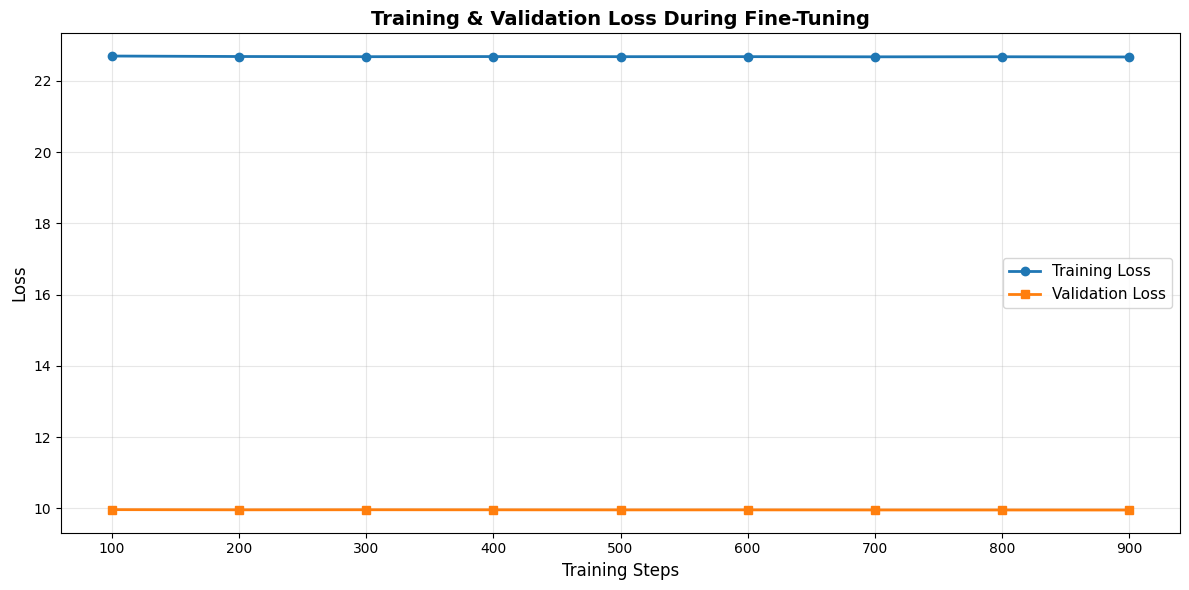


=== LOSS SUMMARY ===
Initial Training Loss: 22.6967
Final Training Loss: 22.6704
Training Loss Reduction: 0.0263 (0.12%)

Initial Validation Loss: 9.9654
Final Validation Loss: 9.9551
Validation Loss Reduction: 0.0104 (0.10%)

Best Validation Loss: 9.9551 (Step 900)


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from training history
log_history = trainer.state.log_history

# Separate training and validation metrics
train_steps = []
train_losses = []
val_steps = []
val_losses = []

for log in log_history:
    step = log.get('step')
    
    if 'loss' in log and 'eval_loss' not in log:
        # Training loss (logged every logging_steps)
        train_steps.append(step)
        train_losses.append(log['loss'])
    
    if 'eval_loss' in log:
        # Validation loss (logged every eval_steps)
        val_steps.append(step)
        val_losses.append(log['eval_loss'])

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(train_steps, train_losses, marker='o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(val_steps, val_losses, marker='s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss During Fine-Tuning', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== LOSS SUMMARY ===")
print(f"Initial Training Loss: {train_losses[0]:.4f}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Training Loss Reduction: {train_losses[0] - train_losses[-1]:.4f} ({100 * (train_losses[0] - train_losses[-1]) / train_losses[0]:.2f}%)")
print(f"\nInitial Validation Loss: {val_losses[0]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Validation Loss Reduction: {val_losses[0] - val_losses[-1]:.4f} ({100 * (val_losses[0] - val_losses[-1]) / val_losses[0]:.2f}%)")
print(f"\nBest Validation Loss: {min(val_losses):.4f} (Step {val_steps[val_losses.index(min(val_losses))]})")